![hypo](../imgs/hypo.png)

# Гипотезы

## Гипотеза 1

Уровень образования не является значимым фактором в требованиях к ИТ-специалистам

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [6]:
final_df = pd.read_csv('final_df.csv')

mask_edu = final_df['education'].notna()
data_pie = final_df.loc[mask_edu, 'education']
data_pie = data_pie.value_counts().reset_index()
fig = px.pie(data_pie, names='education', values='count', title='Распределение необходимости в образовании')
fig.show()

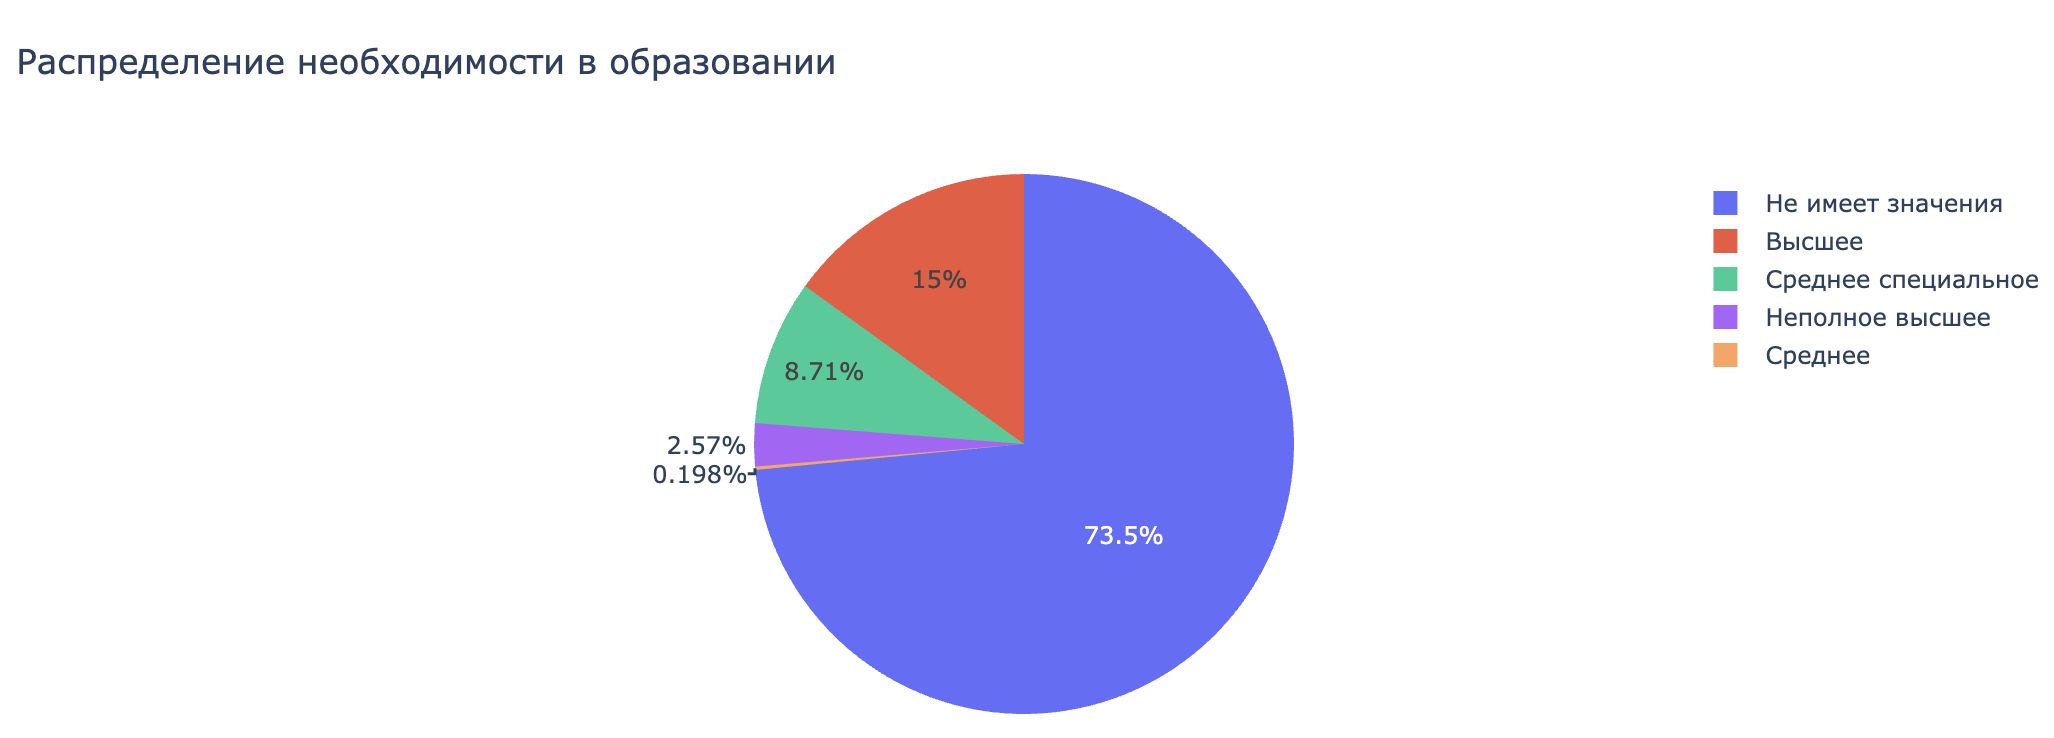

Из заполненных данных по этому признаку в нашем датасете для 73,5% ИТ-вакансий образование не имеет значения.

## Гипотеза 2

H0: зарплата не зависит от опыта

H1: зарплата различается по уровню опыта

Воспользуемся замечательной картинкой от Андрея Сусова, чтобы определить, какой стат критерий нам подойдет для оценки стат значимости.

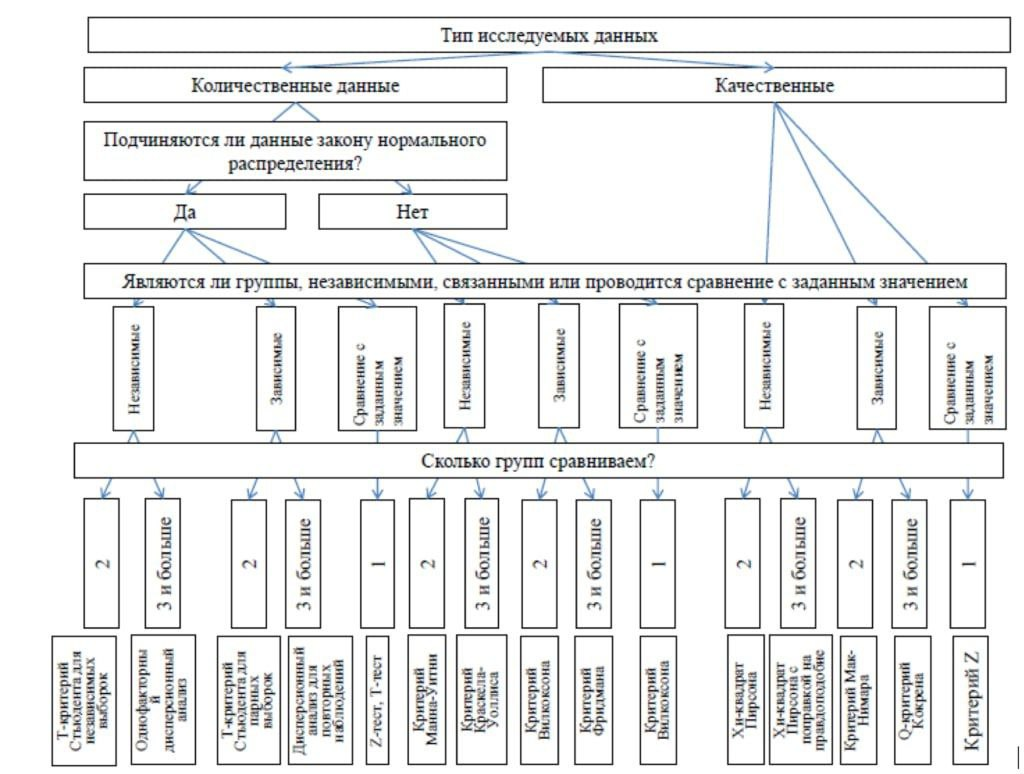

In [3]:
# проверим на нормальность

from scipy.stats import shapiro

print(shapiro(final_df['salary'].dropna()))

ShapiroResult(statistic=0.1014482403997321, pvalue=1.426360462575535e-82)


pvalue < 0.05 => отвергаем нулевую гипотезу о нормальности распределения в пользу альтернативной о не нормальности распределения

Итак, мы исследуем количественные данные (зп), не нормально распределенные, независимых групп у нас 4 => подходит критерий Краскела-Уоллиса. 

In [8]:
import pandas as pd
final_df = pd.read_csv('final_df.csv')

In [9]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


[дока kruskal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html)

In [12]:
from scipy.stats import kruskal

group1 = final_df[final_df['experience'] == 0]['salary'].dropna()
group2 = final_df[final_df['experience'] == 1]['salary'].dropna()
group3 = final_df[final_df['experience'] == 3]['salary'].dropna()
group4 = final_df[final_df['experience'] == 6]['salary'].dropna()
kruskal(group1,group2,group3,group4)

KruskalResult(statistic=np.float64(567.8123451278323), pvalue=np.float64(9.570204086438798e-123))

pvalue<0.05 => отклоняем нулевую гипотезу в пользу альтернативной о том, что зарплата различается по уровню опыта.

Бизнес-ценность: 
- образовательному бизнесу важно делать упор на практику, чтобы можно было засчитывать ее как реальный опыт
- а также стоит партнериться с компаниями, чтобы ученики решали реальные рабочие кейсы